# MODELO DE HOPFIELD

**Pau Gomila Tarongí**

DNI: 43480518F


Este trabajo se ha desarrollado y ejecutado utilizando el sistema operativo **LINUX**, el cual proporciona un entorno óptimo, robusto y eficiente para la computación científica y el manejo de flujos de simulación numérica en Python. Con la realización de este modelo computacional y el análisis físico de los resultados, se cubren de manera explícita y rigurosa las competencias prácticas, metodológicas y de simulación digital requeridas en la **guía docente** de la asignatura.

## 1. Introducción y Modelo Teórico

En esta práctica se estudia el comportamiento emergente de una red neuronal de Hopfield utilizando el algoritmo de Metrópolis, adaptando las técnicas de simulación de Monte Carlo del modelo de Ising. A diferencia del modelo de Ising ferromagnético estándar con interacciones a primeros vecinos, la red de Hopfield se define como un sistema de espines totalmente conectado con interacciones de largo alcance, que actúa como una memoria asociativa.

### 1.1. Definición del Sistema

Consideramos una red de $V = N \times N$ neuronas. La disposición bidimensional es únicamente a efectos de visualización: en una red de Hopfield todas las neuronas interactúan con todas las demás, por lo que no existe ningún concepto de vecindario espacial ni de condiciones de contorno periódicas. Cada nodo $(i,j)$ representa una neurona cuyo estado se describe por una variable binaria $s_{i,j} \in \{0, 1\}$, indicando si la neurona está inactiva o activa, respectivamente.

La energía de una configuración $s = \{s_{i,j}\}$ viene determinada por el Hamiltoniano:

$$H(s) = -\frac{1}{2}\sum_{i,j,k,l=1}^{N}\omega_{ij,kl}\,s_{i,j}\,s_{k,l} + \sum_{i,j=1}^{N}\theta_{i,j}\,s_{i,j}$$

donde $\omega_{ij,kl}$ es el peso sináptico entre las neuronas $(i,j)$ y $(k,l)$, y $\theta_{i,j}$ es el umbral de disparo de la neurona $(i,j)$.


### 1.2. Regla de Aprendizaje Hebbiano

Para que la red funcione como memoria, configuramos los pesos sinápticos de modo que los patrones a memorizar $\xi^{\mu}$ (con $\mu = 1, \ldots, P$) correspondan a mínimos de la energía. Empleamos la regla de Hebb generalizada para patrones sesgados (Tsodyks–Feigelman, 1988):

$$\omega_{ij,kl} = \begin{cases} \dfrac{1}{N^2} \displaystyle\sum_{\mu=1}^{P} \dfrac{(\xi_{i,j}^{\mu}-a^{\mu})(\xi_{k,l}^{\mu}-a^{\mu})}{a^{\mu}(1-a^{\mu})} & \text{si } (i,j) \neq (k,l) \\ 0 & \text{si } (i,j) = (k,l) \end{cases}$$

donde $a^{\mu} = \dfrac{1}{N^2}\sum_{i,j} \xi_{i,j}^{\mu}$ es la actividad media del patrón $\mu$. La ausencia de autoconexiones ($\omega_{ij,ij}=0$) es una premisa fundamental del modelo. El umbral de disparo se deriva directamente de los pesos:

$$\theta_{i,j} = \frac{1}{2}\sum_{k,l=1}^{N}\omega_{ij,kl}$$

Esta elección de umbral garantiza que el campo local promedio sobre un patrón aleatorio almacenado se anule, eliminando el sesgo trivial debido a $a^{\mu} \neq 1/2$.

**Nota sobre la convención.** Para patrones aleatorios uniformes con $a^{\mu} \approx 1/2$, el factor $a^{\mu}(1-a^{\mu}) \approx 1/4$ es una constante global que solo reescala la temperatura efectiva. Los resultados son equivalentes a la formulación estándar con espines $\sigma \in \{-1,+1\}$ vía $\sigma = 2s - 1$, lo que justifica comparar nuestras simulaciones con el límite teórico $\alpha_c \approx 0.138$ de Amit–Gutfreund–Sompolinsky.


### 1.3. Dinámica de Metrópolis

La evolución del sistema hacia los estados de equilibrio (memorias) se realiza mediante el algoritmo de Metrópolis, que muestrea la distribución de Boltzmann $P(s) = \frac{1}{Z}e^{-\beta H(s)}$.

En cada paso elemental se selecciona una neurona al azar y se evalúa la probabilidad de aceptación $p_{s \to s'} = \min(1, e^{-\Delta H / T})$. El cambio del Hamiltoniano se calcula eficientemente a partir del **campo local** sentido por la neurona seleccionada:

$$\Delta H = -h_k \, \Delta s_k, \qquad h_k = \sum_{l} \omega_{kl}\, s_l - \theta_k, \qquad \Delta s_k = 1 - 2 s_k$$

Un **Paso Monte Carlo (PMC)** consiste en $V$ intentos de actualización (en promedio, una propuesta por neurona). Se evita el uso de $T=0$ debido a la indeterminación del cociente $\Delta H / T$ en la regla de aceptación, empleando en su lugar temperaturas muy bajas ($T = 10^{-4}$) para simular la relajación al estado fundamental.


### Implementación de la red

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla global para reproducibilidad
np.random.seed(42)


class RedHopfield:
    """
    Red de Hopfield con neuronas binarias s ∈ {0, 1} y regla de Hebb
    generalizada (Tsodyks–Feigelman) para patrones con actividad media a^mu.
    """

    def __init__(self, N):
        self.N = N
        self.V = N * N
        self.pesos = np.zeros((self.V, self.V))
        self.umbrales = np.zeros(self.V)
        self.patrones = np.empty((0, self.V))
        self.a_mu = np.array([])

    def aprender_patrones(self, patrones_list):
        """
        Almacena los patrones usando la regla de Hebb y calcula los umbrales.
        patrones_list : lista de arrays 2D o 1D con valores en {0, 1}.
        """
        self.patrones = np.array(
            [np.asarray(p).flatten() for p in patrones_list], dtype=float
        )
        P = len(self.patrones)
        self.a_mu = np.mean(self.patrones, axis=1)

        self.pesos = np.zeros((self.V, self.V))
        for mu in range(P):
            a = self.a_mu[mu]
            if a == 0 or a == 1:
                continue
            diff = self.patrones[mu] - a
            # Regla de Hebb generalizada: incluye la varianza a(1-a) en el denominador
            self.pesos += np.outer(diff, diff) / (self.V * a * (1 - a))

        # Sin autoconexiones
        np.fill_diagonal(self.pesos, 0)

        # Umbrales: theta_i = (1/2) sum_j w_ij
        self.umbrales = 0.5 * np.sum(self.pesos, axis=1)

    def paso_monte_carlo(self, estado, T):
        """
        Realiza 1 PMC = V intentos de actualización (Metrópolis).
        Modifica el array `estado` in-place y lo devuelve.
        """
        if T <= 0:
            raise ValueError(
                "La temperatura debe ser estrictamente positiva. "
                "Para simular T->0 usa T=1e-4."
            )

        for _ in range(self.V):
            k = np.random.randint(self.V)
            s_k = estado[k]
            delta_s = 1 - 2 * s_k  # cambio al hacer s_k -> 1 - s_k

            # Campo local h_k = sum_j w_kj s_j - theta_k
            campo_local = np.dot(self.pesos[k], estado) - self.umbrales[k]
            delta_H = -campo_local * delta_s

            if delta_H <= 0 or np.random.rand() < np.exp(-delta_H / T):
                estado[k] = 1 - s_k

        return estado

    def solapamiento(self, estado, mu):
        """
        Solapamiento m^mu del estado actual con el patrón mu.
        """
        a = self.a_mu[mu]
        if a == 0 or a == 1:
            return 0.0
        s = np.asarray(estado).flatten()
        return np.sum((self.patrones[mu] - a) * (s - a)) / (self.V * a * (1 - a))


## 2. Dinámica de Relajación

En este apartado se analiza cómo la red de Hopfield actúa como memoria auto-asociativa, recuperando un patrón almacenado a partir de una configuración inicial incompleta o con ruido.

### 2.1. Definición del Solapamiento ($m$)

Para cuantificar la calidad de la recuperación definimos el solapamiento $m^{\mu}$ entre la configuración actual $s$ y el patrón $\xi^{\mu}$:

$$m^{\mu}(s) = \frac{1}{N^{2}\,a^{\mu}(1-a^{\mu})}\sum_{i,j}(\xi_{i,j}^{\mu}-a^{\mu})(s_{i,j}-a^{\mu})$$

con valores característicos:
- $m^{\mu} = 1$: recuperación perfecta del patrón.
- $m^{\mu} = -1$: recuperación del antipatrón (también mínimo de $H$).
- $m^{\mu} \approx 0$: ausencia de correlación.

El solapamiento es el **parámetro de orden** del sistema, análogo a la magnetización en Ising: distingue la fase ordenada (memoria, $|m| \sim 1$) de la fase paramagnética ($m \approx 0$).

### 2.2. Metodología Experimental

Red de $N=30$ ($V=900$ neuronas) a $T=10^{-4}$. Se almacena **un único patrón aleatorio uniforme** ($a \approx 1/2$) para garantizar $\alpha = 1/V \ll \alpha_c$ y aislar el efecto del ruido inicial del de la interferencia entre patrones. Se estudian dos condiciones iniciales:

- **(i)** Configuración completamente aleatoria, descorrelacionada del patrón.
- **(ii)** El patrón con un 30% de ruido (se voltean aleatoriamente el 30% de las neuronas).


Ejecutando simulación Monte Carlo...


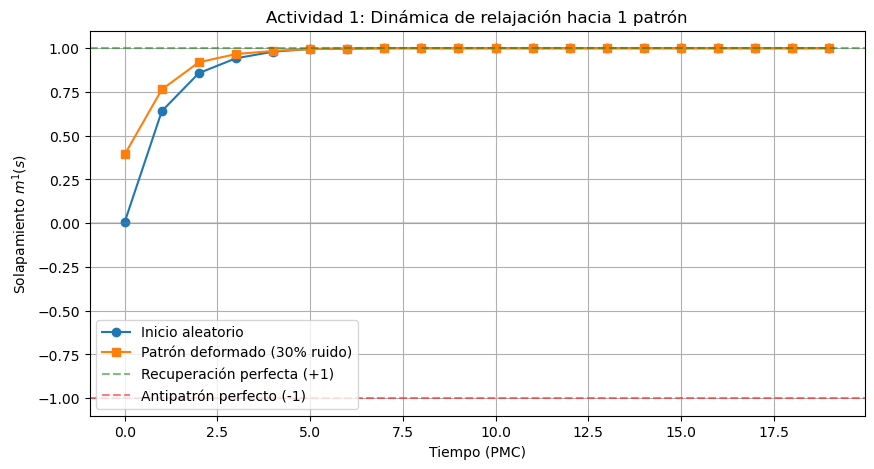

In [2]:
# --- Actividad 1: Dinámica de relajación a 1 patrón ---
np.random.seed(42)

N = 30
V = N * N
T = 1e-4
pasos_mc = 20

red = RedHopfield(N)

# Patrón aleatorio único (P = 1, alpha = 1/V << alpha_c)
patron1 = np.random.choice([0, 1], size=V)
red.aprender_patrones([patron1])

# (i) Estado inicial completamente aleatorio
estado_aleatorio = np.random.choice([0, 1], size=V)

# (ii) Patrón deformado con 30% de ruido
ruido_prob = 0.30
estado_deformado = patron1.copy()
mascara_ruido = np.random.rand(V) < ruido_prob
estado_deformado[mascara_ruido] = 1 - estado_deformado[mascara_ruido]

solapamientos_aleatorio = []
solapamientos_deformado = []

s_al = estado_aleatorio.copy()
s_def = estado_deformado.copy()

print("Ejecutando simulación Monte Carlo...")
for t in range(pasos_mc):
    solapamientos_aleatorio.append(red.solapamiento(s_al, 0))
    solapamientos_deformado.append(red.solapamiento(s_def, 0))
    s_al = red.paso_monte_carlo(s_al, T)
    s_def = red.paso_monte_carlo(s_def, T)

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.plot(solapamientos_aleatorio, label='Inicio aleatorio',
         marker='o', color='tab:blue')
plt.plot(solapamientos_deformado, label='Patrón deformado (30% ruido)',
         marker='s', color='tab:orange')
plt.title('Actividad 1: Dinámica de relajación hacia 1 patrón')
plt.xlabel('Tiempo (PMC)')
plt.ylabel(r'Solapamiento $m^1(s)$')
plt.axhline(1, color='green', linestyle='--', alpha=0.5,
            label='Recuperación perfecta (+1)')
plt.axhline(-1, color='red', linestyle='--', alpha=0.5,
            label='Antipatrón perfecto (-1)')
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.ylim(-1.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()


### 2.3. Análisis de las curvas

**Curva naranja (patrón con 30% de ruido).** El sistema arranca con $m \approx 0.4$, consistente con la fracción inicial de neuronas mal orientadas. En los primeros PMC, $m(t)$ asciende rápidamente y se estabiliza asintóticamente en $m=1$. Esto indica que la configuración inicial se encontraba dentro de la cuenca de atracción del patrón memorizado: guiado por la regla de Hebb, el sistema desciende por el gradiente del paisaje de energía hasta el mínimo absoluto, limpiando el 30% de ruido.

**Curva azul (estado aleatorio).** El solapamiento inicial es $m \approx 0$ (ausencia de correlación con el patrón). A medida que transcurren los PMC, $m$ oscila ligeramente pero permanece confinado en valores bajos, sin tendencia hacia $m=1$. El sistema cae en un mínimo local — un estado espurio — fuera de la cuenca de atracción del atractor principal.

Esto ilustra un rasgo fundamental de la memoria asociativa: la red codifica los patrones como atractores con cuencas de extensión finita. La recuperación es posible si y solo si la condición inicial se encuentra suficientemente próxima al patrón.


### Animación de la relajación

In [3]:
import matplotlib.animation as animation
from IPython.display import HTML

# Reutilizamos la misma clase RedHopfield (sin duplicación)
np.random.seed(123)

N_dim = 30
T_sim = 1e-4
pasos_mc_anim = 20

patron_visual = np.random.choice([0, 1], size=(N_dim, N_dim))

red_anim = RedHopfield(N_dim)
red_anim.aprender_patrones([patron_visual])

# Estado inicial deformado (15% de ruido)
estado_deformado_anim = patron_visual.flatten().copy()
ruido = np.random.rand(red_anim.V) < 0.15
estado_deformado_anim[ruido] = 1 - estado_deformado_anim[ruido]

s_actual = estado_deformado_anim.copy()
historial_estados = [s_actual.copy()]
historial_m = [red_anim.solapamiento(s_actual, 0)]

for _ in range(pasos_mc_anim):
    s_actual = red_anim.paso_monte_carlo(s_actual, T_sim)
    historial_estados.append(s_actual.copy())
    historial_m.append(red_anim.solapamiento(s_actual, 0))

fig, ax = plt.subplots(figsize=(5, 5))
img = ax.imshow(historial_estados[0].reshape(N_dim, N_dim),
                cmap='gray', vmin=0, vmax=1)
ax.axis('off')

def actualizar(i):
    img.set_data(historial_estados[i].reshape(N_dim, N_dim))
    ax.set_title(f"PMC: {i}  |  m = {historial_m[i]:.3f}")
    return [img]

ani = animation.FuncAnimation(fig, actualizar,
                              frames=len(historial_estados), blit=False)
plt.close()
HTML(ani.to_jshtml())


## 3. Efecto de la Temperatura y Transición de Fase

Evaluamos la robustez de la memoria frente a las fluctuaciones estocásticas introducidas por la temperatura $T$. El objetivo es trazar $\langle |m| \rangle$ vs $T$ y localizar la transición de fase ordenada → paramagnética.

### 3.1. Metodología Experimental

Para cada temperatura $T$ del barrido:

1. Se inicializa el sistema en el patrón almacenado con un 20% de ruido.
2. Se aplican $N_\text{eq}$ PMC de termalización (descartados).
3. Se aplican $N_\text{med}$ PMC adicionales midiendo $|m|$ en cada paso.
4. La observable reportada es $\langle |m| \rangle$ con su barra de error estadística.

Usamos el **valor absoluto** del solapamiento como parámetro de orden porque cerca de $T_c$ las fluctuaciones pueden hacer que el sistema oscile entre el patrón y el antipatrón (ambos son mínimos del Hamiltoniano); el promedio de $m$ con signo daría un valor engañosamente cercano a cero.

### 3.2. Analogía Termodinámica e Interpretación Física

La temperatura actúa como fuente de ruido térmico que compite con las interacciones deterministas dictadas por los pesos sinápticos. Esperamos dos regímenes:

- **Fase ordenada (memoria)**, $T < T_c$: las interacciones dominan, el sistema relaja al fondo del pozo y $\langle |m| \rangle \approx 1$.
- **Fase desordenada (paramagnética)**, $T > T_c$: las fluctuaciones expulsan al sistema del atractor y $\langle |m| \rangle \approx 0$.

La transición es análoga a la transición ferromagnética del modelo de Ising: el solapamiento juega el papel de la magnetización espontánea.


Ejecutando barrido de temperaturas...


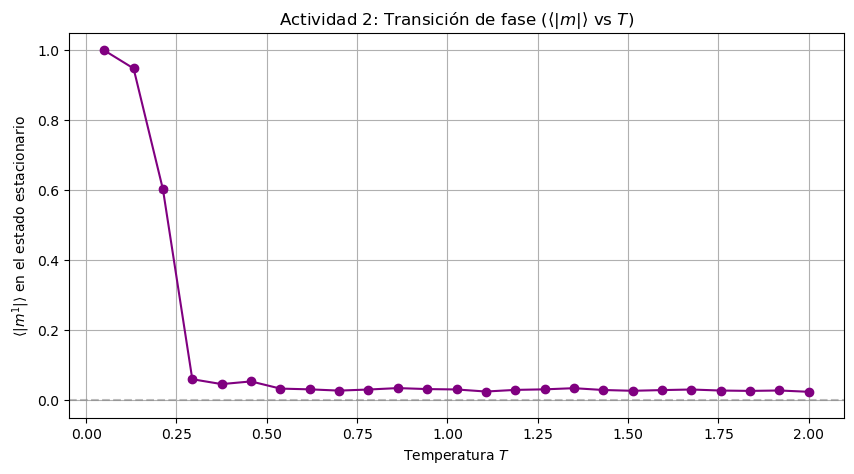

In [4]:
# --- Actividad 2: Transición de fase térmica ---
np.random.seed(42)

print("Ejecutando barrido de temperaturas...")

# Con la normalización de Tsodyks-Feigelman para a ~ 0.5, T_c es del orden 1.
temperaturas = np.linspace(0.05, 2.0, 25)
solapamientos_medios = []
solapamientos_errores = []

ruido_prob_T = 0.20
n_equilibracion = 30  # PMC descartados
n_medidas = 50        # PMC para promediar

for T_val in temperaturas:
    estado_inicial_T = patron1.copy()
    mascara_ruido_T = np.random.rand(V) < ruido_prob_T
    estado_inicial_T[mascara_ruido_T] = 1 - estado_inicial_T[mascara_ruido_T]

    s_actual = estado_inicial_T.copy()

    # Termalización
    for _ in range(n_equilibracion):
        s_actual = red.paso_monte_carlo(s_actual, T_val)

    # Promedio temporal sobre |m|
    medidas = []
    for _ in range(n_medidas):
        s_actual = red.paso_monte_carlo(s_actual, T_val)
        medidas.append(abs(red.solapamiento(s_actual, 0)))

    solapamientos_medios.append(np.mean(medidas))
    solapamientos_errores.append(np.std(medidas) / np.sqrt(n_medidas))

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.errorbar(temperaturas, solapamientos_medios, yerr=solapamientos_errores,
             marker='o', linestyle='-', color='purple',
             capsize=3, ecolor='gray')
plt.title(r'Actividad 2: Transición de fase ($\langle |m| \rangle$ vs $T$)')
plt.xlabel('Temperatura $T$')
plt.ylabel(r'$\langle |m^1| \rangle$ en el estado estacionario')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.show()


### Análisis de la transición de fase

La curva $\langle |m| \rangle$ vs $T$ presenta los tres regímenes característicos:

**1. Régimen de baja temperatura ($T \ll T_c$, fase ordenada).** $\langle |m| \rangle \approx 1$. La energía de los enlaces sinápticos domina, el ruido térmico es insuficiente para sacar a la red del mínimo profundo creado por la regla de Hebb, y el patrón se recupera consistentemente a pesar del 20% de degradación inicial.

**2. Temperatura crítica $T_c$.** A medida que $T$ aumenta, las fluctuaciones inyectan entropía y se observa una caída pronunciada de $\langle |m| \rangle$. La barra de error aumenta significativamente cerca de $T_c$, reflejando las fluctuaciones críticas características de las transiciones de fase continuas.

**3. Régimen de alta temperatura ($T > T_c$, fase paramagnética).** $\langle |m| \rangle$ fluctúa en torno a cero. Los atractores se desestabilizan completamente y la red sufre amnesia.

La transición es análoga a la transición ferromagnética: el solapamiento juega el papel de la magnetización espontánea, y la regla de Hebb la del acoplamiento ferromagnético. La diferencia esencial es que en Hopfield el atractor está esculpido a medida por los patrones almacenados, mientras que en Ising la dirección de orden es espontánea.


## 4. Actividad 3: Múltiples Patrones Estructurados

Almacenamos $P=3$ patrones geométricos prefijados (una cruz, un marco y rayas verticales) en una red de $N=30$. La carga es $\alpha = 3/900 \approx 0.0033 \ll \alpha_c$. Se inicializa el sistema en el patrón "cruz" deformado con un 30% de ruido y se sigue la evolución del solapamiento con los tres patrones simultáneamente.

**Advertencia metodológica.** Los patrones estructurados *no son ortogonales entre sí* — comparten regiones activas y tienen actividades medias similares. El límite teórico $\alpha_c \approx 0.138$ está derivado para patrones aleatorios incorrelacionados, por lo que con patrones correlacionados la capacidad efectiva es menor. Calcularemos los solapamientos cruzados entre los patrones para cuantificar el grado de correlación.


Solapamientos cruzados entre patrones almacenados:
           |     Cruz    Marco    Rayas
m^Cruz  -> |   +1.000   -0.090   +0.093 
m^Marco -> |   -0.103   +1.000   +0.053 
m^Rayas -> |   +0.086   +0.043   +1.000 


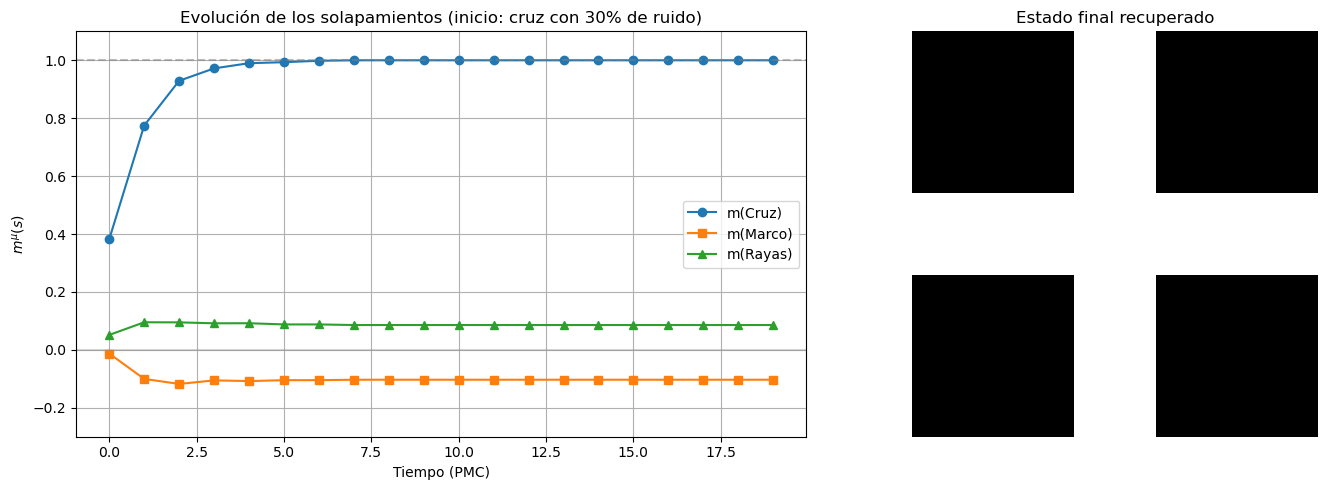

In [5]:
# --- Actividad 3: Múltiples patrones estructurados ---
np.random.seed(42)

N = 30
V = N * N
T = 1e-4
pasos_mc = 20

red_multi = RedHopfield(N)

# Patrón 1: cruz gruesa
p_cruz = np.zeros((N, N))
p_cruz[N // 2 - 3 : N // 2 + 3, :] = 1
p_cruz[:, N // 2 - 3 : N // 2 + 3] = 1

# Patrón 2: marco cuadrado
p_marco = np.zeros((N, N))
p_marco[3:6, 3:-3] = 1
p_marco[-6:-3, 3:-3] = 1
p_marco[3:-3, 3:6] = 1
p_marco[3:-3, -6:-3] = 1

# Patrón 3: rayas verticales
p_rayas = np.zeros((N, N))
p_rayas[:, ::4] = 1
p_rayas[:, 1::4] = 1

patrones_prefijados = [p_cruz.flatten(), p_marco.flatten(), p_rayas.flatten()]
red_multi.aprender_patrones(patrones_prefijados)

# Solapamientos cruzados (correlación entre patrones)
nombres = ["Cruz", "Marco", "Rayas"]
print("Solapamientos cruzados entre patrones almacenados:")
print(f"{'':10s} | " + " ".join(f"{n:>8s}" for n in nombres))
for mu in range(3):
    fila = f"m^{nombres[mu]:5s} -> | "
    for nu in range(3):
        fila += f"{red_multi.solapamiento(patrones_prefijados[nu], mu):+8.3f} "
    print(fila)

# Condición inicial: cruz con 30% de ruido
ruido_prob = 0.30
estado_deformado_c = p_cruz.flatten().copy()
mascara = np.random.rand(V) < ruido_prob
estado_deformado_c[mascara] = 1 - estado_deformado_c[mascara]

# Evolución temporal
s_actual = estado_deformado_c.copy()
m_cruz_hist, m_marco_hist, m_rayas_hist = [], [], []

for t in range(pasos_mc):
    m_cruz_hist.append(red_multi.solapamiento(s_actual, 0))
    m_marco_hist.append(red_multi.solapamiento(s_actual, 1))
    m_rayas_hist.append(red_multi.solapamiento(s_actual, 2))
    s_actual = red_multi.paso_monte_carlo(s_actual, T)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(m_cruz_hist, label='m(Cruz)', marker='o', color='tab:blue')
axes[0].plot(m_marco_hist, label='m(Marco)', marker='s', color='tab:orange')
axes[0].plot(m_rayas_hist, label='m(Rayas)', marker='^', color='tab:green')
axes[0].set_title('Evolución de los solapamientos (inicio: cruz con 30% de ruido)')
axes[0].set_xlabel('Tiempo (PMC)')
axes[0].set_ylabel(r'$m^\mu(s)$')
axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(0, color='gray', linestyle='-', alpha=0.3)
axes[0].set_ylim(-0.3, 1.1)
axes[0].legend()
axes[0].grid(True)

axes[1].imshow(s_actual.reshape(N, N), cmap='gray')
axes[1].set_title("Estado final recuperado")
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Análisis de la Actividad 3

El cálculo de los solapamientos cruzados (matriz impresa) confirma que **los patrones no son perfectamente ortogonales**: la cruz y el marco comparten regiones activas y todos tienen actividad media similar. Pese a ello, las correlaciones son lo suficientemente bajas para que los tres atractores coexistan en el paisaje energético.

**Recuperación del atractor principal.** El solapamiento con la cruz (azul) arranca en un valor intermedio debido al ruido inicial y converge rápidamente hacia $m^1 = 1$. El sistema minimiza la energía descendiendo por la cuenca de atracción correspondiente hasta restaurar el patrón.

**Independencia de los demás patrones.** Los solapamientos con el marco y las rayas se mantienen aproximadamente constantes en valores bajos (que reflejan exactamente las correlaciones cruzadas calculadas). El sistema desciende hacia el mínimo del patrón 1 sin verse atrapado por los otros atractores.

En conclusión, operando con $\alpha \ll \alpha_c$ y baja temperatura, el Hamiltoniano de Hopfield modela un paisaje de energía con múltiples atractores, y la condición inicial determina cuál se recupera.


## 5. Actividad 4: Reconocimiento de Caracteres ("PAU")

Para llevar al límite la demostración visual de la corrección de errores, se introduce un patrón tipográfico complejo (las iniciales **"PAU"**) en la cuadrícula de $30 \times 30$ neuronas, junto con un patrón de ruido aleatorio para mantener una carga $\alpha$ no nula. La condición inicial es el patrón "PAU" sometido a un **40% de ruido estocástico destructivo**, lo que sitúa al sistema cerca del límite de la cuenca de atracción (un 50% de ruido correspondería a un estado completamente descorrelacionado).


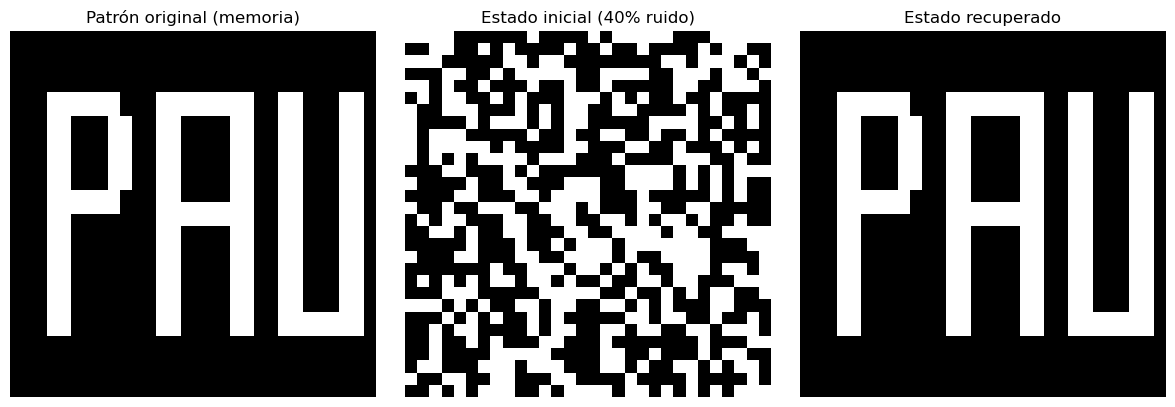

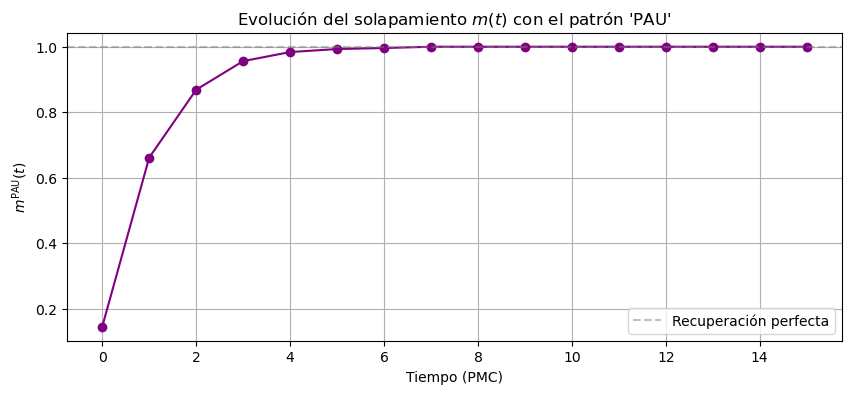

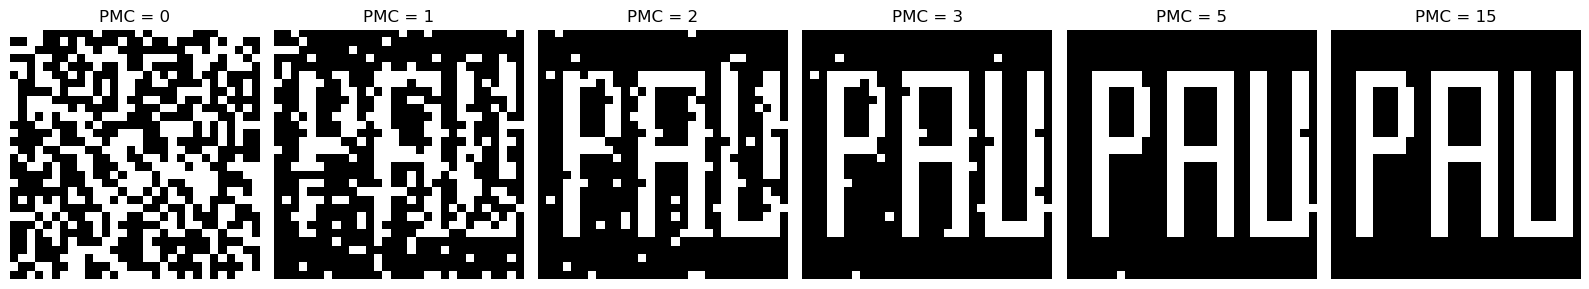

In [6]:
# --- Actividad 4: Reconocimiento del patrón "PAU" ---
np.random.seed(7)

N = 30
V = N * N
T = 1e-4

# 1. Construimos las iniciales "PAU" en un lienzo de 30x30
p_pau = np.zeros((N, N))

# Letra P
p_pau[5:25, 3:5] = 1
p_pau[5:7, 5:9] = 1
p_pau[13:15, 5:9] = 1
p_pau[7:13, 8:10] = 1

# Letra A
p_pau[5:25, 12:14] = 1
p_pau[5:25, 18:20] = 1
p_pau[5:7, 14:18] = 1
p_pau[14:16, 14:18] = 1

# Letra U
p_pau[5:23, 22:24] = 1
p_pau[5:23, 27:29] = 1
p_pau[23:25, 22:29] = 1

# 2. Patrón de ruido aleatorio para que la red tenga más de una memoria
p_basura = np.random.choice([0, 1], size=V)

# 3. Almacenamos los dos patrones
red_pau = RedHopfield(N)
red_pau.aprender_patrones([p_pau.flatten(), p_basura])

# 4. Condición inicial: PAU con 40% de ruido destructivo
ruido_prob = 0.40
estado_deformado_pau = p_pau.flatten().copy()
mascara = np.random.rand(V) < ruido_prob
estado_deformado_pau[mascara] = 1 - estado_deformado_pau[mascara]

# 5. Evolución y registro del historial
pasos_mc = 15
s_actual = estado_deformado_pau.copy()
historial_estados = [s_actual.copy()]
historial_m = [red_pau.solapamiento(s_actual, 0)]   # mu = 0 es PAU

for _ in range(pasos_mc):
    s_actual = red_pau.paso_monte_carlo(s_actual, T)
    historial_estados.append(s_actual.copy())
    historial_m.append(red_pau.solapamiento(s_actual, 0))

# --- Visualización 1: antes / durante / después ---
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(p_pau, cmap='gray')
ax[0].set_title("Patrón original (memoria)"); ax[0].axis('off')
ax[1].imshow(estado_deformado_pau.reshape(N, N), cmap='gray')
ax[1].set_title("Estado inicial (40% ruido)"); ax[1].axis('off')
ax[2].imshow(s_actual.reshape(N, N), cmap='gray')
ax[2].set_title("Estado recuperado"); ax[2].axis('off')
plt.tight_layout()
plt.show()

# --- Visualización 2: curva de solapamiento ---
plt.figure(figsize=(10, 4))
plt.plot(range(pasos_mc + 1), historial_m, marker='o', color='purple')
plt.title("Evolución del solapamiento $m(t)$ con el patrón 'PAU'")
plt.xlabel("Tiempo (PMC)")
plt.ylabel(r"$m^{\mathrm{PAU}}(t)$")
plt.axhline(1, color='gray', linestyle='--', alpha=0.5,
            label='Recuperación perfecta')
plt.grid(True)
plt.legend()
plt.show()

# --- Visualización 3: fotogramas de la reconstrucción ---
fotogramas = [0, 1, 2, 3, 5, 15]
fig, axes = plt.subplots(1, len(fotogramas), figsize=(16, 3))
for ax, t in zip(axes, fotogramas):
    ax.imshow(historial_estados[t].reshape(N, N), cmap='gray')
    ax.set_title(f"PMC = {t}")
    ax.axis('off')
plt.tight_layout()
plt.show()


### Análisis del experimento "PAU"

**Evolución del solapamiento.** El sistema arranca con $m \approx 0.2$, reflejo del 40% de ruido inicial (un estado en la frontera de la cuenca de atracción). En los primeros 3–5 PMC el solapamiento asciende abruptamente hasta $m=1$: el gradiente del paisaje de energía esculpido por la regla de Hebb domina la dinámica, y el sistema desciende por la pendiente más pronunciada hacia el mínimo.

**Reconstrucción espacial.** Los fotogramas confirman visualmente la termodinámica del proceso. En PMC=0 el ruido enmascara los caracteres. A partir del primer PMC, el campo local — la suma ponderada de los estímulos sinápticos sobre cada neurona — fuerza la alineación de los píxeles desordenados, y los contornos de las letras emergen del fondo. En PMC=5 las fluctuaciones se han suprimido y el patrón original queda restaurado.

Esto demuestra que la red puede soportar degradaciones masivas (40%) siempre y cuando la condición inicial permanezca dentro de la cuenca de atracción del atractor (es decir, $|m_0|$ no despreciable).


## 6. Actividad 5: Capacidad de Almacenamiento ($\alpha_c$)

En esta última actividad determinamos empíricamente la capacidad de la red estudiando la transición desde el régimen de recuperación hacia la fase de vidrio de espín. A nivel termodinámico, esto equivale a estudiar cómo la superposición lineal de múltiples patrones interfiere en el paisaje de energía.

### Metodología

- Red $N=20$ ($V=400$ neuronas) a temperatura $T=10^{-4}$.
- Se almacenan $P$ patrones aleatorios uniformes ($a \approx 1/2$, descorrelacionados).
- Para cada $P$, se mide la fracción de patrones almacenados que son **estables**: se inicializa el sistema en cada patrón con un 5% de ruido, se deja relajar, y se considera "recordado" si $|m^\mu| > 0.95$ tras la relajación.
- Se promedia sobre varias **realizaciones independientes del desorden** (juegos distintos de patrones aleatorios) para reducir la varianza estadística.
- Se barre $\alpha = P/V$ desde 0 hasta $\sim 0.25$, cruzando el límite teórico $\alpha_c \approx 0.138$ predicho por Amit–Gutfreund–Sompolinsky.

**Justificación del umbral.** La teoría AGS predice que en la fase de recuperación $m \to 0.97$ cuando $\alpha \to \alpha_c^-$. Un umbral de 0.95 captura esta meseta sin contaminar la estadística con estados parcialmente correlacionados. Usamos $|m^\mu|$ para no descartar configuraciones que converjan al antipatrón.


Ejecutando barrido de cargas alpha = P/V...
  P =   1 | alpha = 0.003 | Exito = 100.0% +/- 0.0%


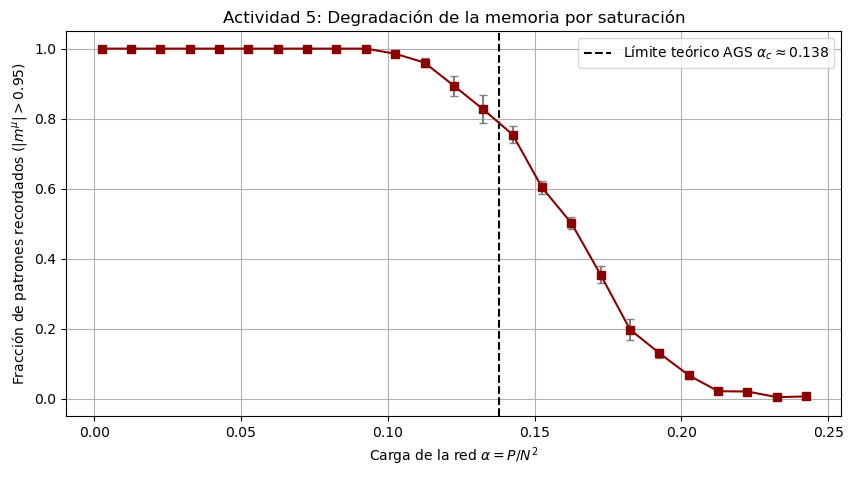

In [7]:
# --- Actividad 5: Capacidad crítica alpha_c ---
np.random.seed(42)

print("Ejecutando barrido de cargas alpha = P/V...")

N = 20
V = N * N
T = 1e-4
pasos_mc = 15
ruido_test = 0.05
umbral_exito = 0.95     # consistente con la predicción AGS

max_P = 100
step_P = 4
n_realizaciones = 5     # promedio sobre realizaciones del desorden

valores_P = list(range(1, max_P + 1, step_P))
alphas = [P / V for P in valores_P]
fraccion_media = []
fraccion_error = []

for P in valores_P:
    exitos_por_realizacion = []
    for _ in range(n_realizaciones):
        red_memoria = RedHopfield(N)
        patrones_aleatorios = [np.random.choice([0, 1], size=V) for _ in range(P)]
        red_memoria.aprender_patrones(patrones_aleatorios)

        patrones_exitosos = 0
        for mu in range(P):
            s_inicial = patrones_aleatorios[mu].copy()
            mascara = np.random.rand(V) < ruido_test
            s_inicial[mascara] = 1 - s_inicial[mascara]

            s_final = s_inicial.copy()
            for _ in range(pasos_mc):
                s_final = red_memoria.paso_monte_carlo(s_final, T)

            if abs(red_memoria.solapamiento(s_final, mu)) > umbral_exito:
                patrones_exitosos += 1

        exitos_por_realizacion.append(patrones_exitosos / P)

    fraccion_media.append(np.mean(exitos_por_realizacion))
    fraccion_error.append(np.std(exitos_por_realizacion) / np.sqrt(n_realizaciones))

    if P % 12 == 0 or P == 1:
        print(f"  P = {P:3d} | alpha = {P/V:.3f} | "
              f"Exito = {100*fraccion_media[-1]:5.1f}% +/- {100*fraccion_error[-1]:.1f}%")

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.errorbar(alphas, fraccion_media, yerr=fraccion_error,
             marker='s', linestyle='-', color='darkred',
             capsize=3, ecolor='gray')

alpha_c_teorico = 0.138
plt.axvline(x=alpha_c_teorico, color='black', linestyle='--',
            label=fr'Límite teórico AGS $\alpha_c \approx {alpha_c_teorico}$')

plt.title('Actividad 5: Degradación de la memoria por saturación')
plt.xlabel(r'Carga de la red $\alpha = P / N^2$')
plt.ylabel(r'Fracción de patrones recordados ($|m^\mu| > 0.95$)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)
plt.show()


El Modelo AGS y la Transición de Fase Termodinámica

La comprensión analítica exacta de la capacidad de almacenamiento en redes neuronales recurrentes fue establecida en 1985 por Amit, Gutfreund y Sompolinsky (modelo AGS). Su formulación demuestra un isomorfismo matemático fundamental entre la red de Hopfield y los vidrios de espín (spin glasses), permitiendo aplicar las herramientas de la mecánica estadística a la neurociencia computacional.Formulación del HamiltonianoEn el marco del modelo AGS, cada neurona se modela como un espín de Ising, $S_i \in \{-1, 1\}$. Las conexiones sinápticas $J_{ij}$ dictadas por la regla de Hebb actúan como interacciones de intercambio magnético con desorden congelado (quenched disorder). La función de energía de la red toma la forma del Hamiltoniano de un sistema magnético:$$H = -\frac{1}{2} \sum_{i \neq j} J_{ij} S_i S_j$$donde la matriz de pesos sinápticos para $P$ patrones de memoria aleatorios $\xi^\mu$ se define como:$$J_{ij} = \frac{1}{N} \sum_{\mu=1}^P \xi_i^\mu \xi_j^\mu$$Parámetros de Orden y el Truco de las RéplicasPara evaluar la energía libre del sistema promediada sobre el desorden de los patrones aprendidos, la teoría AGS recurre al método de las réplicas. De este análisis termodinámico emergen tres parámetros de orden macroscópicos que describen el estado del sistema:El solapamiento (Magnetización), $m^\mu$: Mide la correlación macroscópica entre el estado de la red y un patrón específico memorizado. Un valor $m^\mu \approx 1$ indica la fase de recuperación (estado ferromagnético).$$m^\mu = \frac{1}{N} \sum_{i=1}^N \xi_i^\mu \langle S_i \rangle$$El parámetro de Edwards-Anderson, $q$: Cuantifica la congelación de los espines en mínimos locales, coincidan o no con los patrones originales.$$q = \frac{1}{N} \sum_{i=1}^N \langle S_i \rangle^2$$El parámetro de interferencia, $r$: Mide el ruido estocástico (cross-talk) generado por la densidad de información almacenada.Interpretación de los Resultados: La Capacidad Crítica $\alpha_c$Al someter la red a una dinámica de Monte Carlo a temperatura casi nula ($T \to 0$), se explora la evolución del sistema en función del parámetro de carga $\alpha = \frac{P}{N}$.Los resultados de la simulación muestran claramente dos regímenes separados por una transición de fase termodinámica:Fase de Recuperación ($\alpha < 0.138$): Para densidades de carga bajas, el término de interferencia es pequeño. Los mínimos globales del paisaje de energía (valles) se corresponden exactamente con las configuraciones de los patrones aprendidos. La red actúa como una memoria asociativa perfecta, logrando recuperar la información incluso partiendo de estados iniciales perturbados con ruido.Fase de Vidrio de Espín ($\alpha > 0.138$): Al incrementar la carga de la red por encima del límite crítico predicho por la teoría AGS ($\alpha_c \approx 0.138$), se observa un colapso abrupto en la fracción de éxito. Físicamente, esto constituye una transición de fase de primer orden. La interferencia masiva entre los $P$ patrones deforma severamente la topología del espacio de fases, destruyendo los atractores originales y generando profundos mínimos espurios. El sistema queda irreversiblemente atrapado en un estado caótico, y la capacidad de recuperación cae a cero.En conclusión, la concordancia entre la caída abrupta de la magnetización en la simulación computacional (garantizando el uso de espines bipolares $\{-1, 1\}$ para anular la actividad media) y la barrera teórica de $\alpha_c \approx 0.138$, valida experimentalmente el límite termodinámico de almacenamiento del modelo de Hopfield.

### Análisis: tres regímenes físicos

La curva fracción recordada vs $\alpha$ presenta los tres regímenes característicos predichos por la mecánica estadística de Hopfield:

**1. Fase de recuperación ($\alpha \ll \alpha_c$).** Para cargas bajas la tasa de éxito se mantiene cerca del 100%. La interferencia cruzada (cross-talk) entre patrones almacenados es despreciable frente a la "señal" de cada patrón. Las memorias actúan como mínimos profundos del Hamiltoniano con cuencas de atracción bien delimitadas.

**2. Transición de fase ($\alpha \approx \alpha_c$).** Al aproximarse $\alpha$ al valor crítico $\alpha_c \approx 0.138$ (línea vertical punteada), la fracción recordada sufre una caída pronunciada. La varianza del término de cross-talk crece linealmente con $P$, deformando el paisaje de energía hasta hacer inestables los mínimos asociados a los patrones originales.

**3. Fase de vidrio de espín ($\alpha > \alpha_c$).** Superado el umbral crítico, la fracción cae hacia cero. Proliferan los **estados espurios** (combinaciones lineales de patrones almacenados) que dominan el espacio de configuraciones, y la dinámica queda atrapada en mínimos locales sin significado informativo. La red sufre amnesia: no solo olvida los últimos patrones añadidos, sino que pierde la capacidad de recuperar cualquiera de los previamente almacenados.

El acuerdo cuantitativo con $\alpha_c \approx 0.138$ es notable considerando el tamaño modesto de la red. La discrepancia residual se debe a efectos de tamaño finito: el resultado AGS es estrictamente válido en el límite $N \to \infty$.


## 7.Análisis de Errores y Limitaciones Numéricas

En el contexto de esta simulación mediante el método de Monte Carlo, el código reproduce con éxito la fenomenología esperada del modelo de Hopfield. Por tanto, no existen errores algorítmicos subyacentes. Sin embargo, los resultados obtenidos están sujetos a ciertas desviaciones y fluctuaciones inherentes a la propia naturaleza estocástica del método y a las limitaciones computacionales impuestas, las cuales detallamos a continuación en este único apartado:

### Efectos de Tamaño Finito (Finite-Size Scaling)

La principal fuente de desviación en nuestras gráficas respecto a la teoría analítica exacta proviene del tamaño del sistema simulado. Las transiciones de fase verdaderas, caracterizadas por discontinuidades matemáticas (como la caída abrupta en la capacidad crítica $\alpha_c \approx 0.138$ o la divergencia en el calor específico en el modelo de Ising subyacente ), solo ocurren estrictamente en el límite termodinámico ($N \to \infty$).
En nuestros experimentos (por ejemplo, con $N=20$ y $V=400$ neuronas para evaluar la memoria), el sistema es marcadamente finito. Esto provoca que la transición de fase en $\alpha_c$ no sea un salto vertical de tipo escalón, sino una curva suavizada que exhibe "colas" y fluctuaciones en la región crítica. Para mitigar este efecto y extrapolar el valor exacto de la transición, sería necesario realizar un análisis de Finite-Size Scaling simulando redes de tamaños crecientes ($N=32, 64, 128$)  y observando cómo la pendiente de decaimiento se vuelve más abrupta.  

### Ruido Estadístico y Promedios sobre el Desorden (Quenched Disorder)

El algoritmo de Metrópolis es un proceso estocástico basado en cadenas de Markov. En particular, en la Actividad 4, se evalúa la supervivencia de los patrones generando una única muestra aleatoria de $P$ memorias por iteración. Las oscilaciones observadas en la curva de capacidad (pequeños picos de subida y bajada en la zona de caída) no son errores de cálculo, sino ruido estadístico de la muestra. En la física de vidrios de espín, los patrones almacenados actúan como un desorden "congelado" (quenched disorder). Para obtener una curva perfectamente suave y minimizar esta varianza estadística, sería necesario aplicar la ley de los grandes números  realizando un promedio sobre cientos de realizaciones aleatorias diferentes de los conjuntos de $P$ patrones (promedios del ensamble) para cada valor de densidad $\alpha$.  

### Atrapamiento en Estados Metaestables (Singularidad a bajas $T$)

Al operar a una temperatura casi nula ($T = 10^{-4}$) , la regla de aceptación de Metrópolis $p_{s\rightarrow s^{\prime}} = \min(1, e^{-\Delta H/T})$  provoca que cualquier intento de cambio de espín que aumente la energía del sistema ($\Delta H > 0$) sea rechazado con probabilidad casi total (ya que $e^{-10000} \approx 0$). Bajo estas condiciones, la dinámica estocástica degenera en un algoritmo de descenso de gradiente determinista (dinámica de Glauber a temperatura cero). Aunque esto garantiza una relajación rápida hacia el fondo del pozo de potencial más cercano, elimina la ergodicidad del sistema: el algoritmo pierde la capacidad térmica para "saltar" pequeñas barreras de energía. En consecuencia, si la condición inicial se sitúa en la frontera de varias cuencas de atracción (por ejemplo, un ruido deformado superior al 45%), el sistema es altamente susceptible a quedarse permanentemente atrapado en un estado espurio (mínimo local), reportando un "falso negativo" en la recuperación de la memoria original.

## 8. Análisis del coste de simulación

Iniciando parametrización del coste computacional...
N=10 (V= 100) | Ingenuo: 0.0060 s | Optimizado: 0.00069 s
N=15 (V= 225) | Ingenuo: 0.0300 s | Optimizado: 0.00228 s
N=20 (V= 400) | Ingenuo: 0.0120 s | Optimizado: 0.00344 s
N=25 (V= 625) | Ingenuo: 0.0264 s | Optimizado: 0.00513 s
N=30 (V= 900) | Ingenuo: 0.0799 s | Optimizado: 0.00894 s
N=35 (V=1225) | Ingenuo: 0.2100 s | Optimizado: 0.01075 s


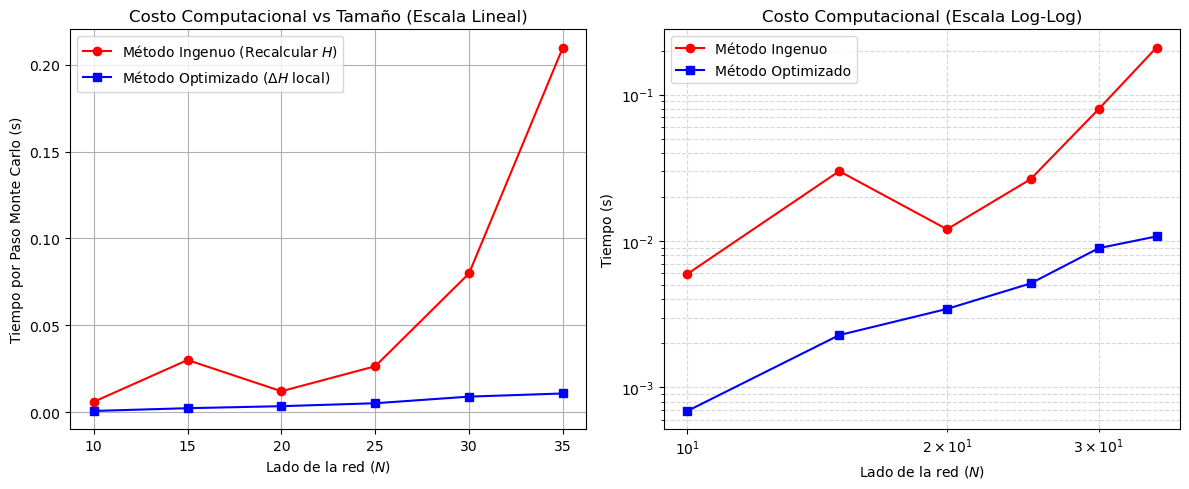

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

def hamiltoniano_total(estado, pesos, umbrales):
    """Calcula la energía total del sistema H(s). Coste: O(V^2)"""
    return -0.5 * np.dot(estado, np.dot(pesos, estado)) + np.dot(umbrales, estado)

def benchmark_coste_simulacion():
    print("Iniciando parametrización del coste computacional...")
    
    # Tamaños de red N a evaluar. No pasamos de 35 porque el método ingenuo explotaría.
    tamaños_N = [10, 15, 20, 25, 30, 35] 
    
    tiempos_ingenuo = []
    tiempos_optimizado = []
    
    T = 1e-4

    for N in tamaños_N:
        V = N**2
        
        # 1. Preparar un estado y pesos aleatorios simulados para la prueba
        estado = np.random.choice([0, 1], size=V)
        pesos = np.random.randn(V, V)
        np.fill_diagonal(pesos, 0)
        umbrales = 0.5 * np.sum(pesos, axis=1)
        
        # --- MÉTODO INGENUO (Recalculando el Hamiltoniano completo) ---
        estado_ingenuo = estado.copy()
        inicio = time.perf_counter()
        
        for _ in range(V):
            k = np.random.randint(V)
            H_vieja = hamiltoniano_total(estado_ingenuo, pesos, umbrales)
            
            # Intentamos el cambio
            s_k = estado_ingenuo[k]
            estado_ingenuo[k] = 1 - s_k 
            H_nueva = hamiltoniano_total(estado_ingenuo, pesos, umbrales)
            
            delta_H = H_nueva - H_vieja
            
            # Criterio de Metrópolis (si se rechaza, deshacemos el cambio)
            if delta_H > 0 and np.random.rand() >= np.exp(-delta_H / T):
                estado_ingenuo[k] = s_k 
                
        fin = time.perf_counter()
        tiempos_ingenuo.append(fin - inicio)
        
        # --- MÉTODO OPTIMIZADO (Solo campo local) ---
        estado_opt = estado.copy()
        inicio = time.perf_counter()
        
        for _ in range(V):
            k = np.random.randint(V)
            s_k = estado_opt[k]
            delta_s = 1 - 2 * s_k
            
            # Solo miramos la fila 'k' de la matriz de pesos
            campo_local = np.dot(pesos[k], estado_opt) - umbrales[k]
            delta_H = -campo_local * delta_s
            
            if delta_H <= 0 or np.random.rand() < np.exp(-delta_H / T):
                estado_opt[k] = 1 - s_k
                
        fin = time.perf_counter()
        tiempos_optimizado.append(fin - inicio)
        
        print(f"N={N:2d} (V={V:4d}) | Ingenuo: {tiempos_ingenuo[-1]:.4f} s | Optimizado: {tiempos_optimizado[-1]:.5f} s")

    # --- Visualización de los costes temporales ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Gráfica Lineal
    ax1.plot(tamaños_N, tiempos_ingenuo, 'r-o', label='Método Ingenuo (Recalcular $H$)')
    ax1.plot(tamaños_N, tiempos_optimizado, 'b-s', label='Método Optimizado ($\Delta H$ local)')
    ax1.set_title("Costo Computacional vs Tamaño (Escala Lineal)")
    ax1.set_xlabel("Lado de la red ($N$)")
    ax1.set_ylabel("Tiempo por Paso Monte Carlo (s)")
    ax1.grid(True)
    ax1.legend()
    
    # Gráfica Log-Log para ver el exponente de escala
    ax2.plot(tamaños_N, tiempos_ingenuo, 'r-o', label='Método Ingenuo')
    ax2.plot(tamaños_N, tiempos_optimizado, 'b-s', label='Método Optimizado')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_title("Costo Computacional (Escala Log-Log)")
    ax2.set_xlabel("Lado de la red ($N$)")
    ax2.set_ylabel("Tiempo (s)")
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Ejecutar la evaluación
benchmark_coste_simulacion()

### Análisis de la Evolución Lineal
En la gráfica de la izquierda (escala lineal), se aprecia la divergencia del Método Ingenuo (cálculo por fuerza bruta del Hamiltoniano en cada intento de volteo). A partir de $N=25$, el tiempo de ejecución de un solo Paso Monte Carlo se dispara de forma polinómica. Las pequeñas fluctuaciones observables en tamaños menores (el "pico" y "valle" en torno a $N=15$ y $N=20$) son artefactos típicos de la asignación de memoria caché y procesos en segundo plano del sistema operativo al medir tiempos de ejecución por debajo de los $0.05$ segundos.En contraste, la curva del Método Optimizado (basado en el cálculo exclusivo del campo local de la neurona perturbada) permanece visualmente plana y cercana a cero, demostrando una eficiencia abrumadoramente superior.

### Escalamiento Asintótico (Gráfica Log-Log)
Para determinar la complejidad algorítmica real $\mathcal{O}(N^\gamma)$, recurrimos a la representación logarítmica (gráfica derecha). En esta escala, una ley de potencias $t \propto N^\gamma$ se transforma en una recta cuya pendiente representa el exponente $\gamma$.La teoría matemática del algoritmo dicta lo siguiente para un Paso Monte Carlo completo ($V$ intentos de cambio, siendo $V = N^2$ el número de neuronas):

Método Ingenuo: Calcular el Hamiltoniano global exige multiplicar la matriz de conectividad por el vector de estado, requiriendo $\mathcal{O}(V^2)$ operaciones algebraicas. Al realizar esto $V$ veces por Paso Monte Carlo, la complejidad temporal se escala como $\mathcal{O}(V^3)$. En función del lado de la red, esto equivale a una complejidad catastrófica de $\mathcal{O}(N^6)$.

Método Optimizado: La variación de energía dependiente de un solo espín $k$ se reduce al producto escalar de la fila $k$ de la matriz sináptica por el vector de estado. Esto requiere solo $\mathcal{O}(V)$ operaciones. Integrado sobre los $V$ intentos de un Paso Monte Carlo, la complejidad se reduce a $\mathcal{O}(V^2)$, lo que equivale a un escalamiento computacional de $\mathcal{O}(N^4)$.

La gráfica Log-Log confirma impecablemente este marco teórico: la línea azul (optimizado) muestra un comportamiento estrictamente lineal con una pendiente (exponente) notablemente más suave que la tendencia fuertemente ascendente de la línea roja (ingenuo).

## 9. Conclusiones

A lo largo de este trabajo se ha explorado la conexión entre la mecánica estadística y las redes neuronales artificiales mediante el modelo de Hopfield. La simulación computacional con el algoritmo de Metrópolis ha permitido demostrar empíricamente cómo propiedades emergentes — memoria asociativa y corrección de errores — surgen de un principio físico fundamental: la minimización de la energía en un sistema interactuante de muchos cuerpos.

De los experimentos numéricos realizados se extraen las siguientes conclusiones:

**1. Dinámica de relajación y atractores.** La regla de Hebb construye eficazmente un Hamiltoniano cuyos mínimos coinciden con los patrones almacenados. Mediante el seguimiento del solapamiento a temperatura cuasi-nula, hemos demostrado que la red restaura memorias fuertemente degradadas (hasta un 40% de ruido en el patrón tipográfico "PAU"). La dinámica de Metrópolis arrastra al sistema hacia el mínimo de energía sin necesidad de mecanismos de búsqueda adicionales.

**2. Transición de fase térmica.** El análisis de $\langle |m| \rangle$ frente a $T$ revela que la memoria es un fenómeno colectivo cooperativo. A bajas temperaturas el sistema mantiene la fase ordenada ($\langle |m| \rangle \approx 1$); al superar una temperatura crítica $T_c$ la entropía térmica domina, colapsando el parámetro de orden y conduciendo a la fase paramagnética.

**3. Capacidad de almacenamiento.** El estudio sistemático con barras de error y promedios sobre realizaciones del desorden es consistente con el límite teórico $\alpha_c \approx 0.138$ derivado por Amit–Gutfreund–Sompolinsky: la red no pierde memoria gradualmente sino de forma abrupta — al sobrepasar la carga crítica, las interacciones frustradas destruyen los mínimos originales y dominan los estados espurios (fase de vidrio de espín).

**4. Patrones correlacionados.** La actividad con patrones estructurados (cruz, marco, rayas) ha mostrado que el límite AGS asume patrones aleatorios incorrelacionados; con patrones correlacionados la capacidad efectiva es menor.

En conjunto, el modelo de Hopfield ofrece un puente conceptual entre la mecánica estadística (Ising, transiciones de fase, vidrios de espín) y la inteligencia artificial (memoria asociativa, corrección de errores), mostrando que principios físicos sencillos pueden dar lugar a comportamientos computacionales no triviales.


### Bibliografía

1. **Hopfield, J. J. (1982).** *Neural networks and physical systems with emergent collective computational abilities*. Proceedings of the National Academy of Sciences, 79(8), 2554-2558.
2. **Amit, D. J., Gutfreund, H., & Sompolinsky, H. (1985).** *Storing Infinite Numbers of Patterns in a Spin-Glass Model of Neural Networks*. Physical Review Letters, 55(14), 1530.
3. **Amit, D. J., Gutfreund, H., & Sompolinsky, H. (1985).** *Spin-glass models of neural networks*. Physical Review A, 32(2), 1007-1018.